In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
faces = fetch_olivetti_faces(shuffle=True, random_state=42)

X = faces.data
y = faces.target

print("========== DATASET ==========")
print("Número de imágenes:", X.shape[0])
print("Número de personas:", len(np.unique(y)))
print("Tamaño de cada imagen:", X.shape[1])

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
========== DATASET ==========
Número de imágenes: 400
Número de personas: 40
Tamaño de cada imagen: 4096


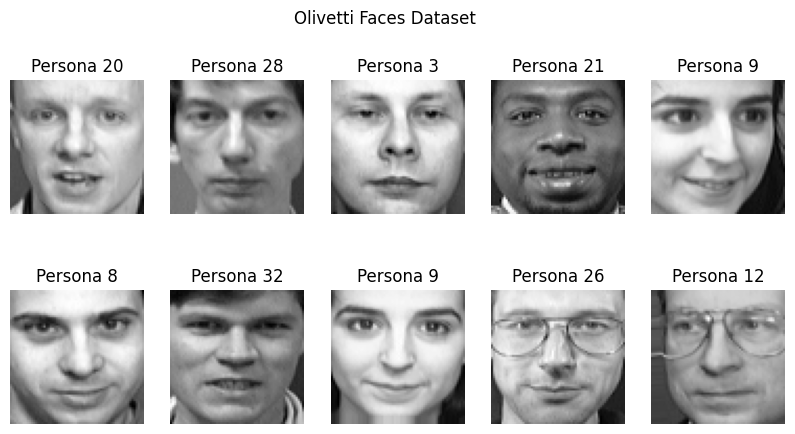

In [ ]:
fig, axes = plt.subplots(2,5, figsize=(10,5))

for ax, img, etiqueta in zip(axes.ravel(), X[:10], y[:10]):
    ax.imshow(img.reshape(64,64), cmap="gray")
    ax.set_title(f"Persona {etiqueta}")
    ax.axis("off")

plt.suptitle("Olivetti Faces Dataset")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (300, 4096)
Prueba: (100, 4096)


In [ ]:
n_componentes = 100

pca = PCA(
    n_components=n_componentes,
    whiten=True,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Antes:", X_train.shape)

print("Después:", X_train_pca.shape)

Antes: (300, 4096)
Después: (300, 100)


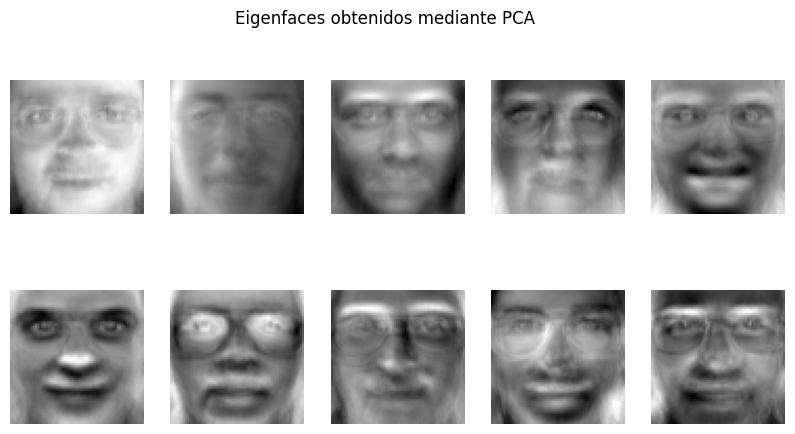

In [ ]:
fig, axes = plt.subplots(2,5, figsize=(10,5))

for ax, comp in zip(axes.ravel(), pca.components_[:10]):
    ax.imshow(comp.reshape(64,64), cmap="gray")
    ax.axis("off")

plt.suptitle("Eigenfaces obtenidos mediante PCA")

plt.show()

In [ ]:
modelo = KNeighborsClassifier(n_neighbors=1)

modelo.fit(X_train_pca, y_train)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
predicciones = modelo.predict(X_test_pca)

precision = accuracy_score(y_test, predicciones)

print("Precisión del reconocimiento:")

print(f"{precision*100:.2f}%")

Precisión del reconocimiento:
92.00%


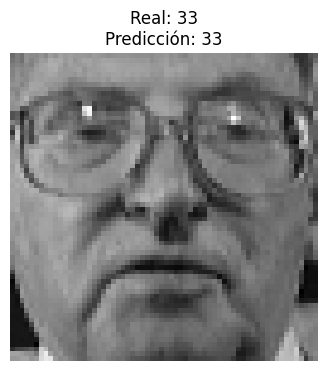

In [ ]:
indice = 8

imagen = X_test[indice]

persona_real = y_test[indice]

persona_predicha = modelo.predict(
    pca.transform([imagen])
)[0]

plt.figure(figsize=(4,4))

plt.imshow(imagen.reshape(64,64), cmap="gray")

plt.axis("off")

plt.title(
    f"Real: {persona_real}\nPredicción: {persona_predicha}"
)

plt.show()